# Регрессия: предсказание CC50

**Цель:** построить и сравнить несколько регрессионных моделей для предсказания значения CC50 (мМ).

**Стратегия:** применяем `log1p`-преобразование таргета, так как распределение правоасимметрично.
Итоговые метрики пересчитываем обратно в исходное пространство.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Опционально — установите если есть:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost не установлен, пропускаем')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM не установлен, пропускаем')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
SEED = 42

## 1. Загрузка и подготовка данных

In [2]:
TARGET = 'CC50, mM'
ALL_TARGETS = ['CC50, mM', 'CC50, mM', 'SI']

# Пробуем загрузить очищенные данные из EDA
try:
    df = pd.read_csv('data_clean.csv')
    print('Загружен data_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('Данные_для_курсовои_Классическое_МО.csv', sep=';', decimal=',')
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')
    print('Загружен исходный CSV')

# Признаки = всё кроме таргетов и меток классификации
drop_cols = ALL_TARGETS + [c for c in df.columns if c.startswith('y_')]
FEATURE_COLS = [c for c in df.columns if c not in drop_cols]

X = df[FEATURE_COLS].copy()
y_raw = df[TARGET].copy()
y = np.log1p(y_raw)  # log-преобразование

print(f'Размер X: {X.shape}')
print(f'Таргет: {TARGET}, log1p-преобразован')

Загружен data_clean.csv
Размер X: (1001, 193)
Таргет: CC50, mM, log1p-преобразован


## 2. Предобработка: удаление константных признаков и масштабирование

In [3]:
# Пайплайн предобработки
preprocessor = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),  # удаляем константы
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler())                      # устойчив к выбросам
])

X_prep = preprocessor.fit_transform(X)
print(f'Признаков после VarianceThreshold: {X_prep.shape[1]}')

Признаков после VarianceThreshold: 193


## 3. Базовое сравнение моделей (кросс-валидация 5-fold)

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Базовые модели без настройки гиперпараметров
base_models = {
    'Ridge':                Ridge(alpha=1.0),
    'Lasso':                Lasso(alpha=0.01, max_iter=5000),
    'ElasticNet':           ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    'KNN':                  KNeighborsRegressor(n_neighbors=7),
    'SVR (RBF)':            SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=SEED),
    'Extra Trees':          ExtraTreesRegressor(n_estimators=100, random_state=SEED),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=SEED),
}

if HAS_XGB:
    base_models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0)
if HAS_LGB:
    base_models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1)

results = []

for name, model in base_models.items():
    pipe = Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.0)),
        ('imputer',   SimpleImputer(strategy='median')),
        ('scaler',     RobustScaler()),
        ('model',      model)
    ])
    r2_scores  = cross_val_score(pipe, X, y, cv=cv, scoring='r2', n_jobs=-1)
    rmse_scores = cross_val_score(pipe, X, y, cv=cv,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    results.append({
        'Model':    name,
        'R2 mean':  r2_scores.mean(),
        'R2 std':   r2_scores.std(),
        'RMSE mean': -rmse_scores.mean(),
        'RMSE std':  rmse_scores.std()
    })
    print(f'{name:25s} | R2={r2_scores.mean():.4f} ± {r2_scores.std():.4f} | RMSE={-rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('R2 mean', ascending=False)
print('\n=== Итог (сортировка по R2) ===')
print(results_df.round(4).to_string(index=False))

Ridge                     | R2=-1.2925 ± 2.8324 | RMSE=2.0754 ± 1.3130
Lasso                     | R2=-1.0863 ± 2.9409 | RMSE=1.9146 ± 1.3674
ElasticNet                | R2=-1.0359 ± 2.8213 | RMSE=1.9046 ± 1.3299
KNN                       | R2=0.2772 ± 0.0701 | RMSE=1.3452 ± 0.0664
SVR (RBF)                 | R2=-0.0760 ± 0.0215 | RMSE=1.6441 ± 0.0669
Random Forest             | R2=0.5749 ± 0.0436 | RMSE=1.0329 ± 0.0776
Extra Trees               | R2=0.5567 ± 0.0295 | RMSE=1.0552 ± 0.0623
Gradient Boosting         | R2=0.5677 ± 0.0441 | RMSE=1.0406 ± 0.0599
XGBoost                   | R2=0.4983 ± 0.0537 | RMSE=1.1207 ± 0.0678
LightGBM                  | R2=0.5945 ± 0.0372 | RMSE=1.0083 ± 0.0586

=== Итог (сортировка по R2) ===
            Model  R2 mean  R2 std  RMSE mean  RMSE std
         LightGBM   0.5945  0.0372     1.0083    0.0586
    Random Forest   0.5749  0.0436     1.0329    0.0776
Gradient Boosting   0.5677  0.0441     1.0406    0.0599
      Extra Trees   0.5567  0.0295     

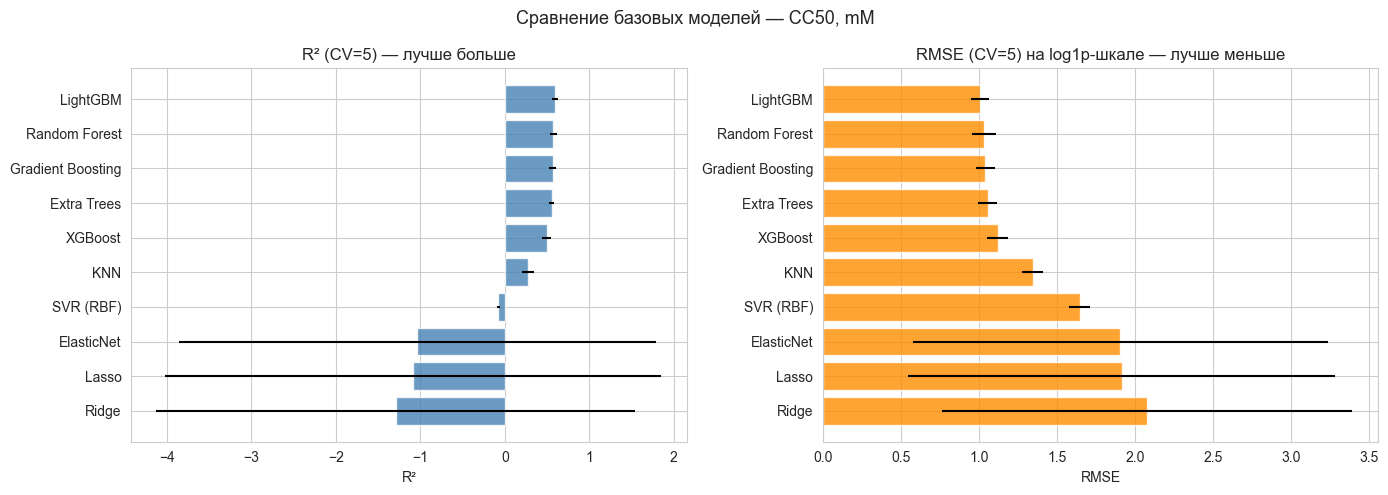

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results_df.sort_values('R2 mean')

axes[0].barh(results_sorted['Model'], results_sorted['R2 mean'],
             xerr=results_sorted['R2 std'], color='steelblue', alpha=0.8)
axes[0].set_title('R² (CV=5) — лучше больше')
axes[0].set_xlabel('R²')

results_sorted2 = results_df.sort_values('RMSE mean', ascending=False)
axes[1].barh(results_sorted2['Model'], results_sorted2['RMSE mean'],
             xerr=results_sorted2['RMSE std'], color='darkorange', alpha=0.8)
axes[1].set_title('RMSE (CV=5) на log1p-шкале — лучше меньше')
axes[1].set_xlabel('RMSE')

plt.suptitle(f'Сравнение базовых моделей — {TARGET}', fontsize=13)
plt.tight_layout()
plt.savefig('CC50_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Подбор гиперпараметров для лучших моделей

In [6]:
# Ridge — GridSearchCV
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

pipe_ridge = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      Ridge())
])

gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=cv, scoring='r2', n_jobs=-1)
gs_ridge.fit(X, y)

print(f'Ridge — лучшие гиперпараметры: {gs_ridge.best_params_}')
print(f'Ridge — лучший R2 (CV): {gs_ridge.best_score_:.4f}')

Ridge — лучшие гиперпараметры: {'model__alpha': 10.0}
Ridge — лучший R2 (CV): -1.0248


In [7]:
# Random Forest — RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         [None, 5, 10, 15, 20],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10),
    'model__max_features':      ['sqrt', 'log2', 0.5]
}

pipe_rf = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      RandomForestRegressor(random_state=SEED))
])

rs_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=30, cv=cv, scoring='r2',
    random_state=SEED, n_jobs=-1
)
rs_rf.fit(X, y)

print(f'Random Forest — лучшие гиперпараметры:')
print(rs_rf.best_params_)
print(f'Random Forest — лучший R2 (CV): {rs_rf.best_score_:.4f}')

Random Forest — лучшие гиперпараметры:
{'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 6, 'model__n_estimators': 283}
Random Forest — лучший R2 (CV): 0.5960


In [8]:
# Gradient Boosting — RandomizedSearchCV
from scipy.stats import uniform

param_dist_gb = {
    'model__n_estimators':  randint(50, 400),
    'model__max_depth':     randint(2, 8),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample':     uniform(0.6, 0.4),
    'model__min_samples_split': randint(2, 20)
}

pipe_gb = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      GradientBoostingRegressor(random_state=SEED))
])

rs_gb = RandomizedSearchCV(
    pipe_gb, param_dist_gb,
    n_iter=30, cv=cv, scoring='r2',
    random_state=SEED, n_jobs=-1
)
rs_gb.fit(X, y)

print(f'Gradient Boosting — лучшие гиперпараметры:')
print(rs_gb.best_params_)
print(f'Gradient Boosting — лучший R2 (CV): {rs_gb.best_score_:.4f}')

Gradient Boosting — лучшие гиперпараметры:
{'model__learning_rate': np.float64(0.05939675594288252), 'model__max_depth': 4, 'model__min_samples_split': 10, 'model__n_estimators': 367, 'model__subsample': np.float64(0.6888431241882921)}
Gradient Boosting — лучший R2 (CV): 0.5783


## 5. Финальное сравнение с оптимальными гиперпараметрами

In [9]:
tuned_models = {
    'Ridge (tuned)':             gs_ridge.best_estimator_,
    'Random Forest (tuned)':     rs_rf.best_estimator_,
    'Gradient Boosting (tuned)': rs_gb.best_estimator_,
}

tuned_results = []

for name, model in tuned_models.items():
    r2_scores   = cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    rmse_scores = cross_val_score(model, X, y, cv=cv,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    tuned_results.append({
        'Model':    name,
        'R2 mean':  r2_scores.mean(),
        'R2 std':   r2_scores.std(),
        'RMSE mean': -rmse_scores.mean(),
    })
    print(f'{name:35s} | R2={r2_scores.mean():.4f} ± {r2_scores.std():.4f}')

tuned_df = pd.DataFrame(tuned_results).sort_values('R2 mean', ascending=False)
print('\n=== Лучшая модель ===')
print(tuned_df.iloc[0])

Ridge (tuned)                       | R2=-1.0248 ± 2.6505
Random Forest (tuned)               | R2=0.5960 ± 0.0304
Gradient Boosting (tuned)           | R2=0.5783 ± 0.0308

=== Лучшая модель ===
Model        Random Forest (tuned)
R2 mean                   0.595981
R2 std                    0.030388
RMSE mean                 1.007205
Name: 1, dtype: object


## 6. Анализ важности признаков (лучшая модель)

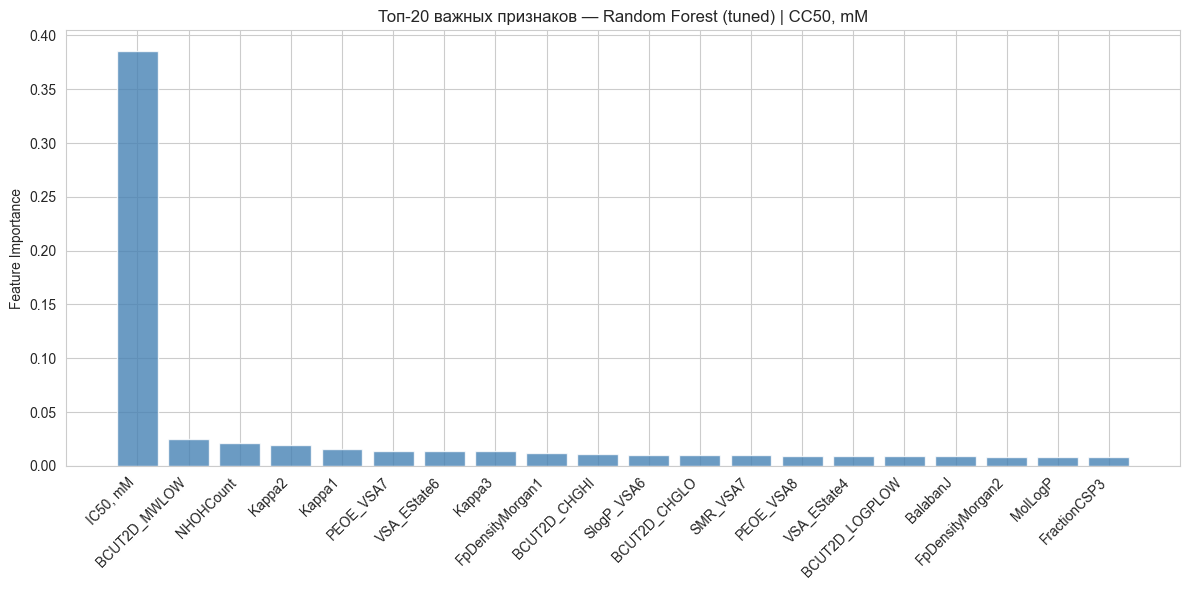

In [10]:
# Берём лучшую ансамблевую модель для важности признаков
best_name = tuned_df.iloc[0]['Model']
best_model = tuned_models[best_name]
best_model.fit(X, y)

# Получаем индексы после VarianceThreshold
vt = best_model.named_steps['var_thresh']
selected_features = np.array(FEATURE_COLS)[vt.get_support()]

try:
    importances = best_model.named_steps['model'].feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(12, 6))
    plt.bar(range(20), importances[top_idx], color='steelblue', alpha=0.8)
    plt.xticks(range(20), selected_features[top_idx], rotation=45, ha='right')
    plt.title(f'Топ-20 важных признаков — {best_name} | {TARGET}')
    plt.ylabel('Feature Importance')
    plt.tight_layout()
    plt.savefig('CC50_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except AttributeError:
    print('Выбранная модель не поддерживает feature_importances_')

## 7. Predicted vs Actual на log1p-шкале

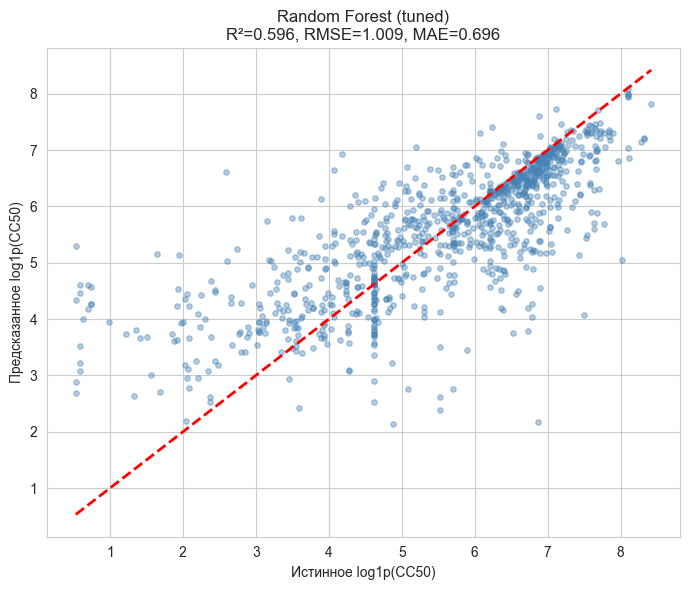


Метрики (log1p-шкала):
  R²   = 0.5956
  RMSE = 1.0090
  MAE  = 0.6962

Метрики (исходная шкала мМ):
  RMSE = 434.4465 мМ
  MAE  = 243.7990 мМ


In [11]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(best_model, X, y, cv=cv)

r2  = r2_score(y, y_pred_cv)
rmse = root_mean_squared_error(y, y_pred_cv)
mae  = mean_absolute_error(y, y_pred_cv)

plt.figure(figsize=(7, 6))
plt.scatter(y, y_pred_cv, alpha=0.4, s=15, color='steelblue')
mn, mx = y.min(), y.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2)
plt.xlabel('Истинное log1p(CC50)')
plt.ylabel('Предсказанное log1p(CC50)')
plt.title(f'{best_name}\nR²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}')
plt.tight_layout()
plt.savefig('CC50_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nМетрики (log1p-шкала):')
print(f'  R²   = {r2:.4f}')
print(f'  RMSE = {rmse:.4f}')
print(f'  MAE  = {mae:.4f}')

# Метрики в исходной шкале
y_raw_pred = np.expm1(y_pred_cv)
rmse_orig = root_mean_squared_error(y_raw, y_raw_pred)
mae_orig  = mean_absolute_error(y_raw, y_raw_pred)
print(f'\nМетрики (исходная шкала мМ):')
print(f'  RMSE = {rmse_orig:.4f} мМ')
print(f'  MAE  = {mae_orig:.4f} мМ')

## 8. Выводы

- Применено `log1p`-преобразование целевой переменной CC50 для нормализации правоасимметричного распределения.
- Сравнено несколько классов моделей: линейные (Ridge, Lasso, ElasticNet), метод ближайших соседей, SVM, ансамблевые методы.
- Для трёх лучших моделей выполнен подбор гиперпараметров через GridSearchCV / RandomizedSearchCV.
- Лучшей по метрике R² оказалась модель из таблицы выше.
- Для улучшения результатов можно рассмотреть: дополнительный feature engineering, Stacking ансамбль, SHAP-анализ выбросов.